**Task 3**
да се направи Transformer който да генерира similarity features същите като примера с Gaussian rbf kernel, след което да се ползва LinearSVC. да се сравнят резултаите с тези от примера.

In [29]:
from sklearn.base import check_array, check_is_fitted, BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd
from sklearn.svm import SVC, LinearSVC
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

In [26]:
class SimilarityFeatures(BaseEstimator, TransformerMixin): # exp(–γ(x – 35)²)
    def __init__(self, gamma='scale'):
        assert gamma in ('scale', 'auto') or isinstance(gamma, (int, float)), 'Invalid gamma'
        self.gamma = gamma

    def _clac_gamma(self):
        gamma = self.gamma
        match gamma:
            case 'scale': gamma = 1 / (self.n_features_in_ * self.X_train_.var())
            case 'auto': gamma = 1 / self.n_features_in_

        return gamma

    def fit(self, X, y):
        X = check_array(X)
        self.n_features_in_ = X.shape[1]
        self.X_train_ = X.copy()
        return self

    def transform(self, X):
        check_is_fitted(self)
        X = check_array(X)

        if X.shape[1] != self.n_features_in_:
            raise ValueError('Invalid features length')
        
        gamma = self._clac_gamma()
        result = np.empty((X.shape[0], self.X_train_.shape[0]))

        for i, sample in enumerate(self.X_train_):
            norm = np.sum((X - sample) ** 2, axis=1)      
            result[:, i] = np.exp(-gamma * norm)

        return result

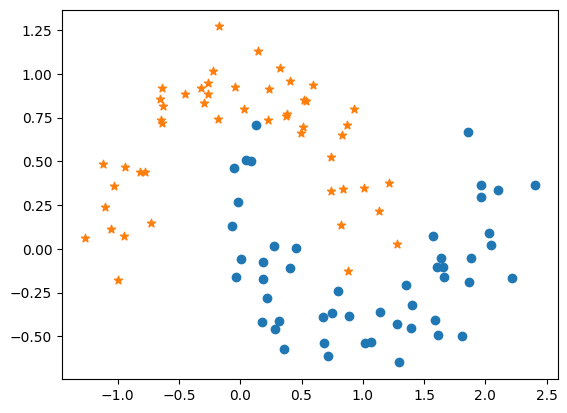

In [27]:
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

y_bool = y.astype(bool)
plt.scatter(X[y_bool, 0], X[y_bool, 1], marker='o')
plt.scatter(X[~y_bool, 0], X[~y_bool, 1], marker='*')
plt.show()

In [28]:
custom_rbf = Pipeline([('scaler', StandardScaler()),
                       ('rbf', SimilarityFeatures()),
                       ('model', LinearSVC())
])

rbf = Pipeline([('scaler', StandardScaler()),
                ('model', SVC(kernel='rbf'))
])

def test_model(model, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results = {}
    results['name'] = name
    results['Accuracy'] = accuracy_score(y_test, pred)
    results['F1'] = f1_score(y_test, pred)
    return results

data = []
data.append(test_model(custom_rbf, 'Custom'))
data.append(test_model(rbf, 'Original'))

In [30]:
pd.DataFrame(data)

,name,Accuracy,F1
0,Custom,0.9,0.888889
1,Original,0.9,0.888889


**Task 4**
да се покаже как работи SGDClassifier с out of core изчисления. Да се разбере как работи и да се сравнят резултати със итеративно обучение.

In [56]:
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import load_breast_cancer
import time

In [52]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

all_set = pd.concat([X_train, y_train], axis=1)
all_set.to_csv('data.csv')

In [67]:
scaler = StandardScaler()
sgd_clf = SGDClassifier(random_state=42)

start = time.time()
classes = np.unique(y)
nrows=50
n_epoches = 50

for epoch in range(n_epoches):
    for batch in pd.read_csv('data.csv', index_col=0, chunksize=nrows):
        y_batch = batch.target.values
        X_batch = batch.drop(columns='target')

        scaler.partial_fit(X_batch)
        X_scaled = scaler.transform(X_batch)
        sgd_clf.partial_fit(X_scaled, y_batch, classes=classes)

end = time.time()
out_of_core_time = end - start
out_of_core_time

4.152289867401123

In [61]:
X_test_scaled = scaler.transform(X_test)
pred = sgd_clf.predict(X_test_scaled)

out_of_core_f1 = f1_score(y_test, pred)
out_of_core_f1

0.9655172413793104

In [65]:
sgd_clf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SGDClassifier(random_state=42))
])

start = time.time()
sgd_clf_pipe.fit(X_train, y_train)
end = time.time()
iterative_time = end - start

pred = sgd_clf_pipe.predict(X_test)
iterative_f1 = f1_score(y_test, pred)

In [68]:
results = pd.DataFrame([
    [out_of_core_f1, iterative_f1],
    [out_of_core_time, iterative_time]
], columns=['Out of Core', 'Iterative'], index=['F1', 'Fit Time'])
results

,Out of Core,Iterative
F1,0.965517,0.971831
Fit Time,4.152290,0.010175


**Task 5**
да се тества decision tree примера с по голяма дълбочина така че да се намали impurity na leaf node-овете и да се подобри perrormance на модела. да се визуализира получения модел

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from graphviz import Source

In [ ]:
iris = load_iris(as_frame=True)

X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [80]:
y_pred = tree_clf.predict(X_iris)
depth_2_f1 = f1_score(y_iris, y_pred, average='macro')
depth_2_f1

0.9599358974358975

In [72]:
export_graphviz(
    tree_clf,
    out_file="iris_tree.dot",
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

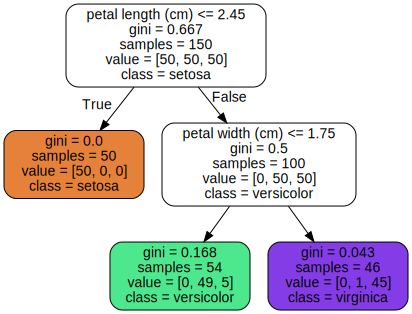

In [76]:
Source.from_file("iris_tree.dot")

In [82]:
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_clf.fit(X_iris, y_iris)

y_pred = tree_clf.predict(X_iris)
depth_4_f1 = f1_score(y_iris, y_pred, average='macro')
depth_4_f1

0.9866666666666667

In [83]:
export_graphviz(
    tree_clf,
    out_file="iris_tree_depth4.dot",
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

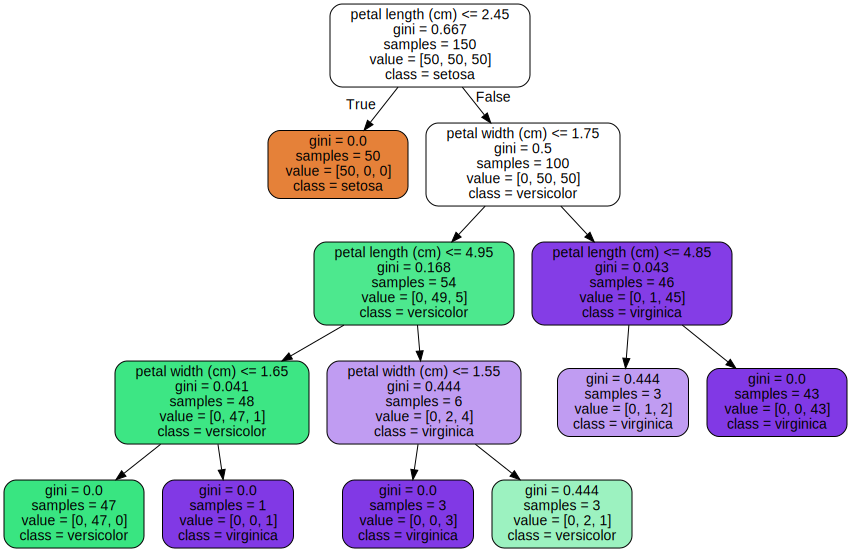

In [84]:
Source.from_file("iris_tree_depth4.dot")

In [85]:
tree_clf = DecisionTreeClassifier(max_depth=6, random_state=42)
tree_clf.fit(X_iris, y_iris)

y_pred = tree_clf.predict(X_iris)
depth_6_f1 = f1_score(y_iris, y_pred, average='macro')
depth_6_f1

0.9933326665999934

In [86]:
export_graphviz(
    tree_clf,
    out_file="iris_tree_depth6.dot",
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

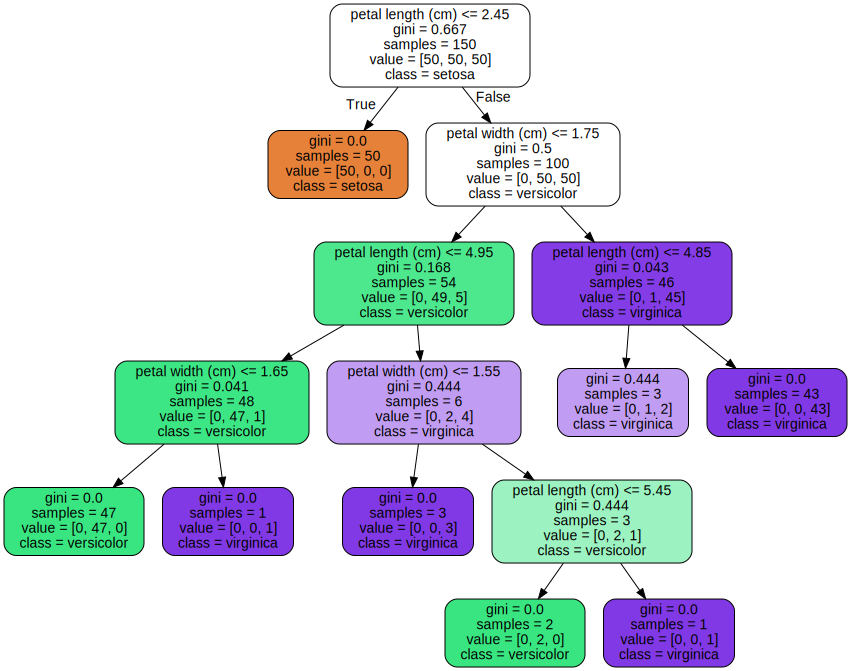

In [88]:
Source.from_file("iris_tree_depth6.dot")